In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'C:\Users\MJ\Desktop')
# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'D:/COVID19'
model_algo="resnet18"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)
test_size = int(0.1 * size)
train_size = int(size - valid_size - test_size)

trainset, validset, testset = random_split(images, (train_size, valid_size, test_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_0.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.1252035246377501, 0.9577483801295896)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.1630269279749701, 0.9449562957713206)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

COVID              0.992233
Lung_Opacity       0.905435
Normal             0.970526
Viral Pneumonia    0.998935
dtype: float64

In [11]:
targetF=[x  for x in each_accu.nsmallest(2).index.map(trainset.dataset.classess)]
targetF

[1, 2]

In [12]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(11302, 3514)

In [13]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(3280, 953)

In [14]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [15]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [16]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [58]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,len(train_dl.dataset.dataset.classes))
    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    elif(data_name=="T" or data_name=="F"):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model



Epoch=0,train_loss=0.008173748064893308,train_accu=0.9985826133909287
Epoch=0,valid_loss=0.021189661373103998,valid_accu=0.9922041105598866
0
Epoch=1,train_loss=0.012430358732821466,train_accu=0.996085313174946
Epoch=1,valid_loss=0.03136133473956716,valid_accu=0.988896763524687
Epoch=2,train_loss=0.007925774329080454,train_accu=0.9972327213822895
Epoch=2,valid_loss=0.028429457694051873,valid_accu=0.9907866761162296
Epoch=3,train_loss=0.05255584338915695,train_accu=0.9822489200863931
Epoch=3,valid_loss=0.10010912775013842,valid_accu=0.9683439640916608
Epoch=4,train_loss=0.000569094589232706,train_accu=0.999865010799136
Epoch=4,valid_loss=0.019458312580890327,valid_accu=0.9955114575950862
0
Epoch=5,train_loss=0.0070746864441475765,train_accu=0.9975026997840173
Epoch=5,valid_loss=0.033030262304687454,valid_accu=0.9900779588944011
Epoch=6,train_loss=0.13256047527832793,train_accu=0.9507289416846653
Epoch=6,valid_loss=0.17318957757680883,valid_accu=0.9411764705882353
Epoch=7,train_loss=0.00

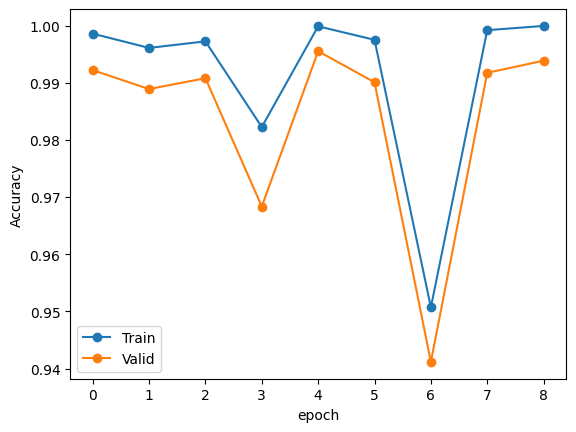

In [59]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.0057880377029076715,train_accu=0.9985771200910644
Epoch=0,valid_loss=0.014579453900141754,valid_accu=0.9968520461699895
0
Epoch=1,train_loss=0.0027909473051975905,train_accu=0.9997154240182129
Epoch=1,valid_loss=0.018170940523975943,valid_accu=0.9968520461699895
Epoch=2,train_loss=0.0035187127956496124,train_accu=0.9997154240182129
Epoch=2,valid_loss=0.01961998424381858,valid_accu=0.9958027282266527
Epoch=3,train_loss=0.0006065547473433941,train_accu=1.0
Epoch=3,valid_loss=0.01232123013391821,valid_accu=0.9979013641133263
0
Epoch=4,train_loss=0.0006851976380564085,train_accu=0.9997154240182129
Epoch=4,valid_loss=0.010542524115145568,valid_accu=0.9989506820566632
0
Epoch=5,train_loss=0.0004651879812541747,train_accu=1.0
Epoch=5,valid_loss=0.012295465488266542,valid_accu=0.9989506820566632
Epoch=6,train_loss=0.0008428760971835569,train_accu=1.0
Epoch=6,valid_loss=0.007059500114079751,valid_accu=0.9979013641133263
Epoch=7,train_loss=0.00040368981658816063,train_accu=1

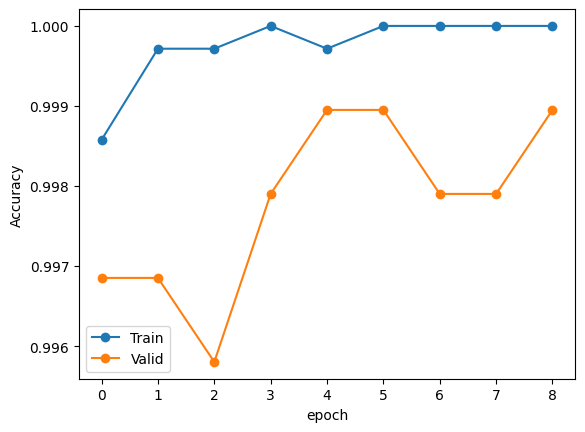

In [60]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.18870997071724996,train_accu=0.9306317465935233
Epoch=0,valid_loss=0.2475675353189794,valid_accu=0.9082317073170731
0
Epoch=1,train_loss=0.057136064830707156,train_accu=0.9791187400460095
Epoch=1,valid_loss=0.1764400991633898,valid_accu=0.9463414634146341
0
Epoch=2,train_loss=0.04579035716219996,train_accu=0.9871704123164041
Epoch=2,valid_loss=0.18272134554458827,valid_accu=0.9378048780487804
Epoch=3,train_loss=0.04428392586028128,train_accu=0.9832772960537958
Epoch=3,valid_loss=0.27843394938901794,valid_accu=0.9378048780487804
Epoch=4,train_loss=0.15366231657744608,train_accu=0.9507166873119802
Epoch=4,valid_loss=0.5456310170679921,valid_accu=0.9179878048780488
Epoch=5,train_loss=0.015034402948351806,train_accu=0.9952220845867988
Epoch=5,valid_loss=0.22604478164235267,valid_accu=0.9405487804878049
4 Early stopping!


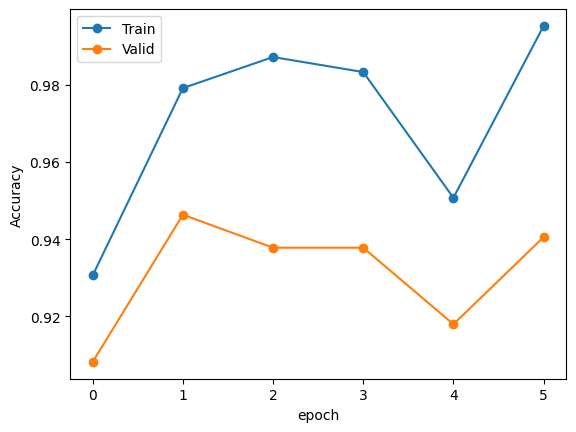

In [61]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [62]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.000569094589232706, 0.999865010799136)

In [63]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.019458312580890327, 0.9955114575950862)

In [64]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0006851975487820236, 0.9997154240182129)

In [65]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.057136064937975704, 0.9791187400460095)

In [66]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.010542522073754649, 0.9989506820566632)

In [67]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.1764400970735928, 0.9463414634146341)

In [68]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.0437472835648302, 0.9840037796976242, 11302)

In [69]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.13909060579957605, 0.9581856839121191, 3280)

In [70]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.044800615308003715, 0.9839362850971922, 11302, 3514)

In [71]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.17626141776101292, 0.9539333805811481, 3273, 960)

In [72]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [73]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.125204,0.957748,0.163027,0.944956
1,Model_Decision,0.000569,0.999865,0.000569,0.995511
2,Model_T,0.000685,0.999715,0.010543,0.998951
3,Model_F,0.057136,0.979119,0.176440,0.946341
4,Total_Model,0.044801,0.983936,0.176261,0.953933
5,Total_Model_without_decision,0.043747,0.984004,0.139091,0.958186


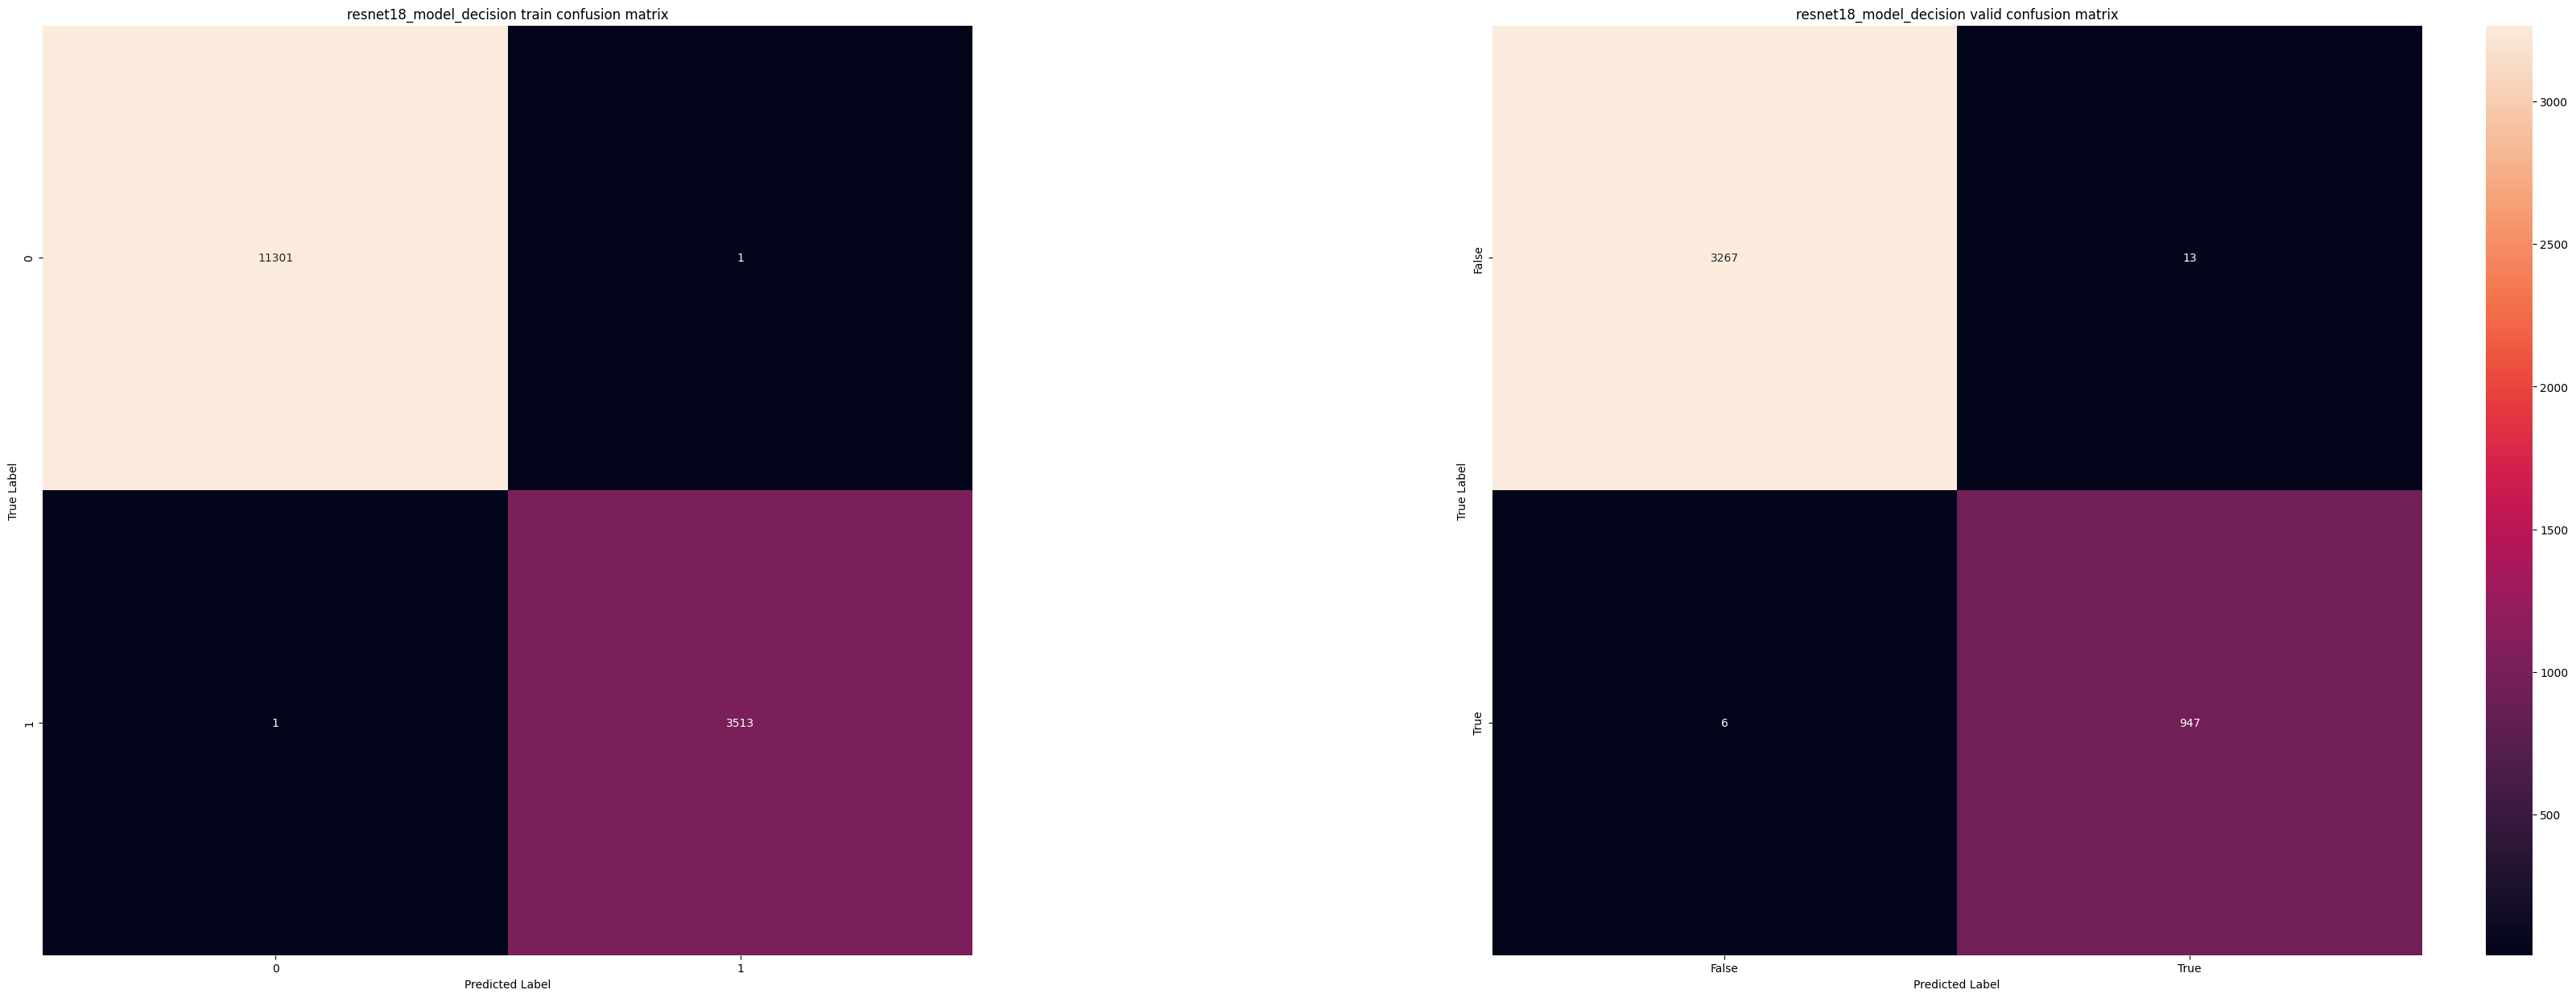

In [74]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

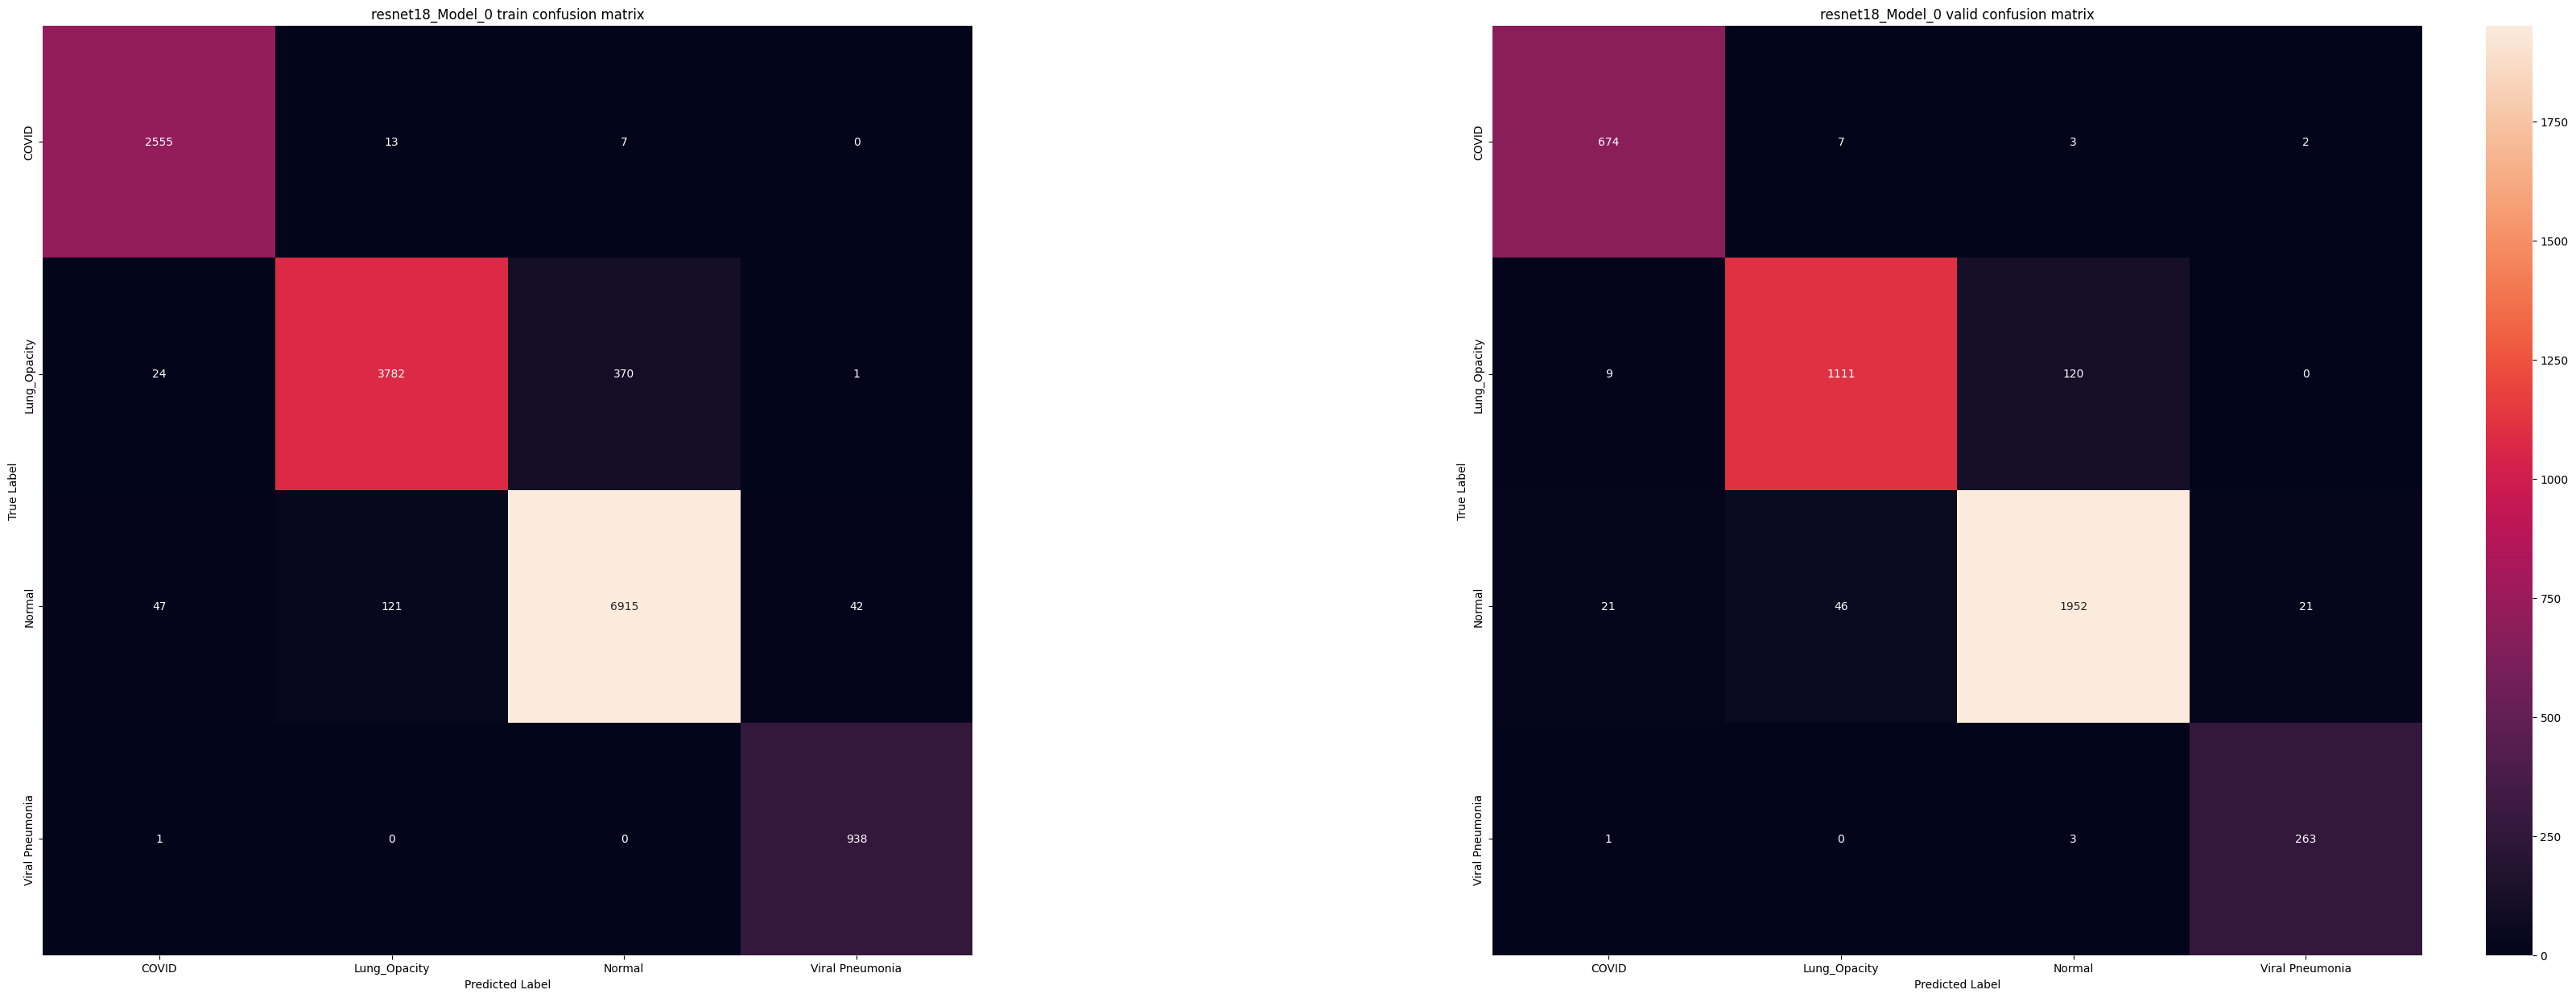

In [75]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

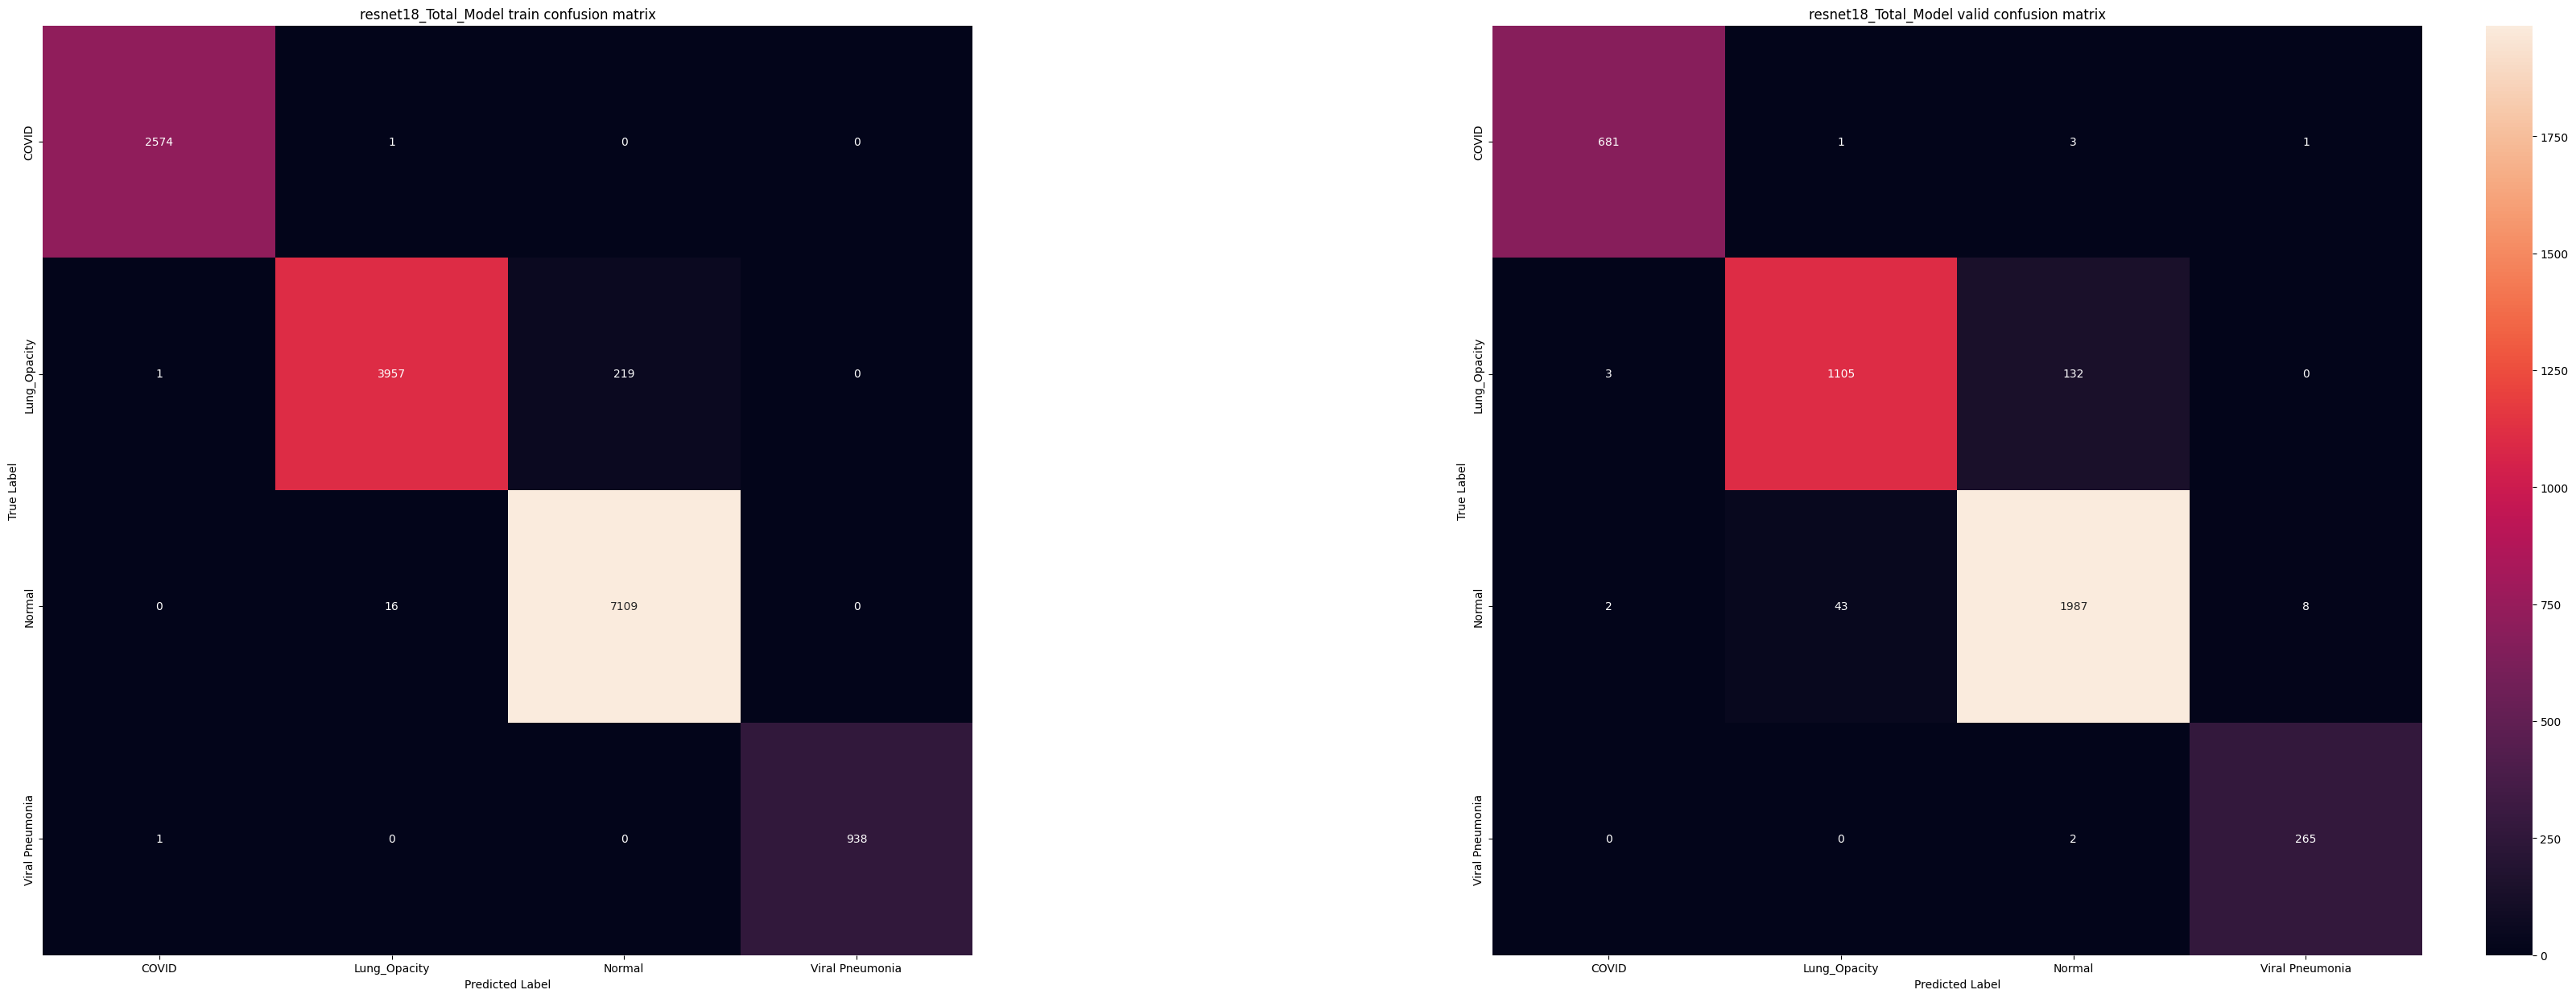

In [76]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

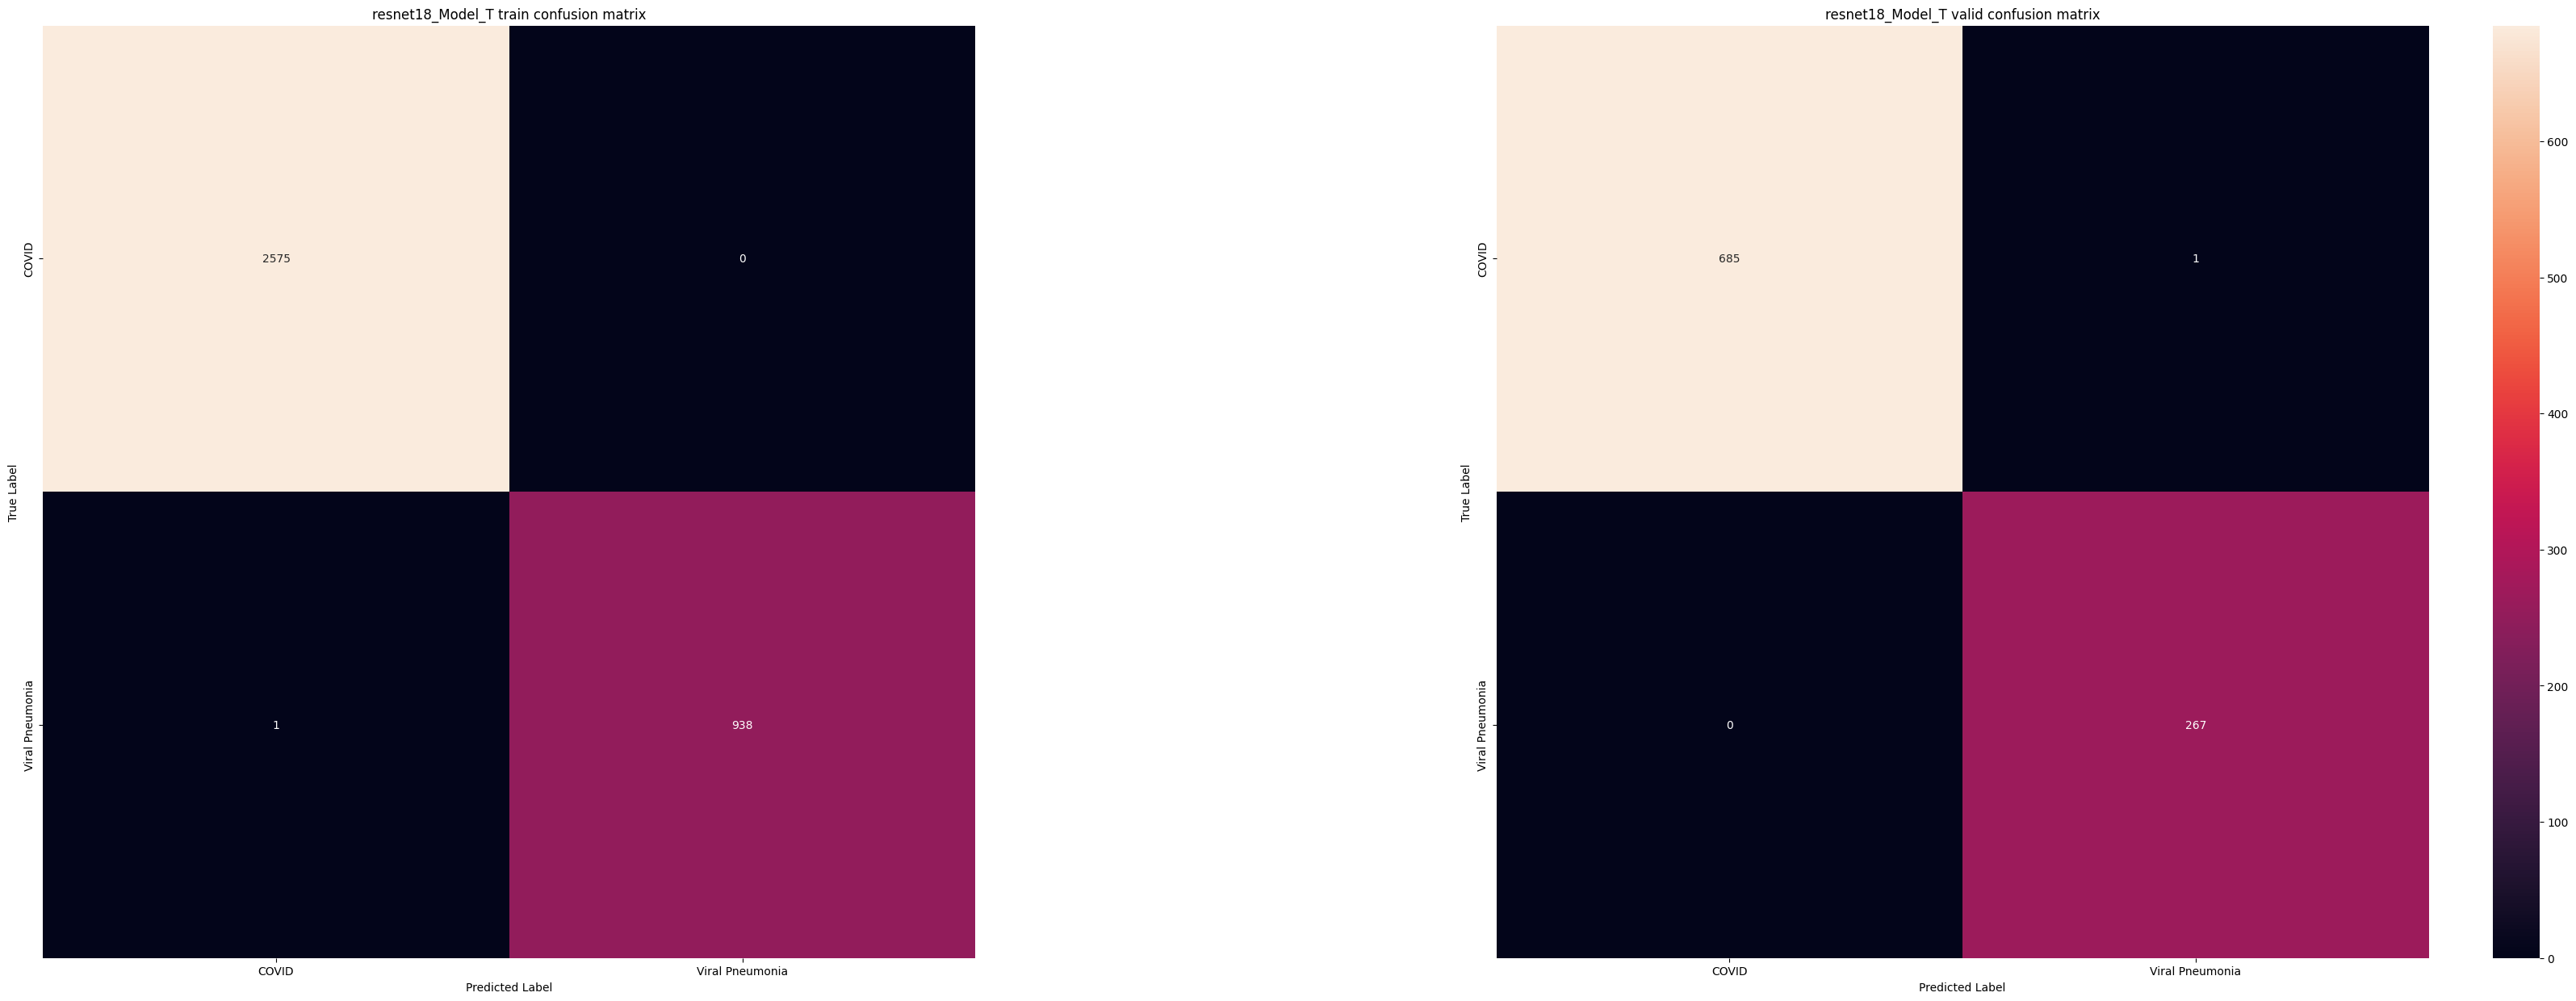

In [77]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

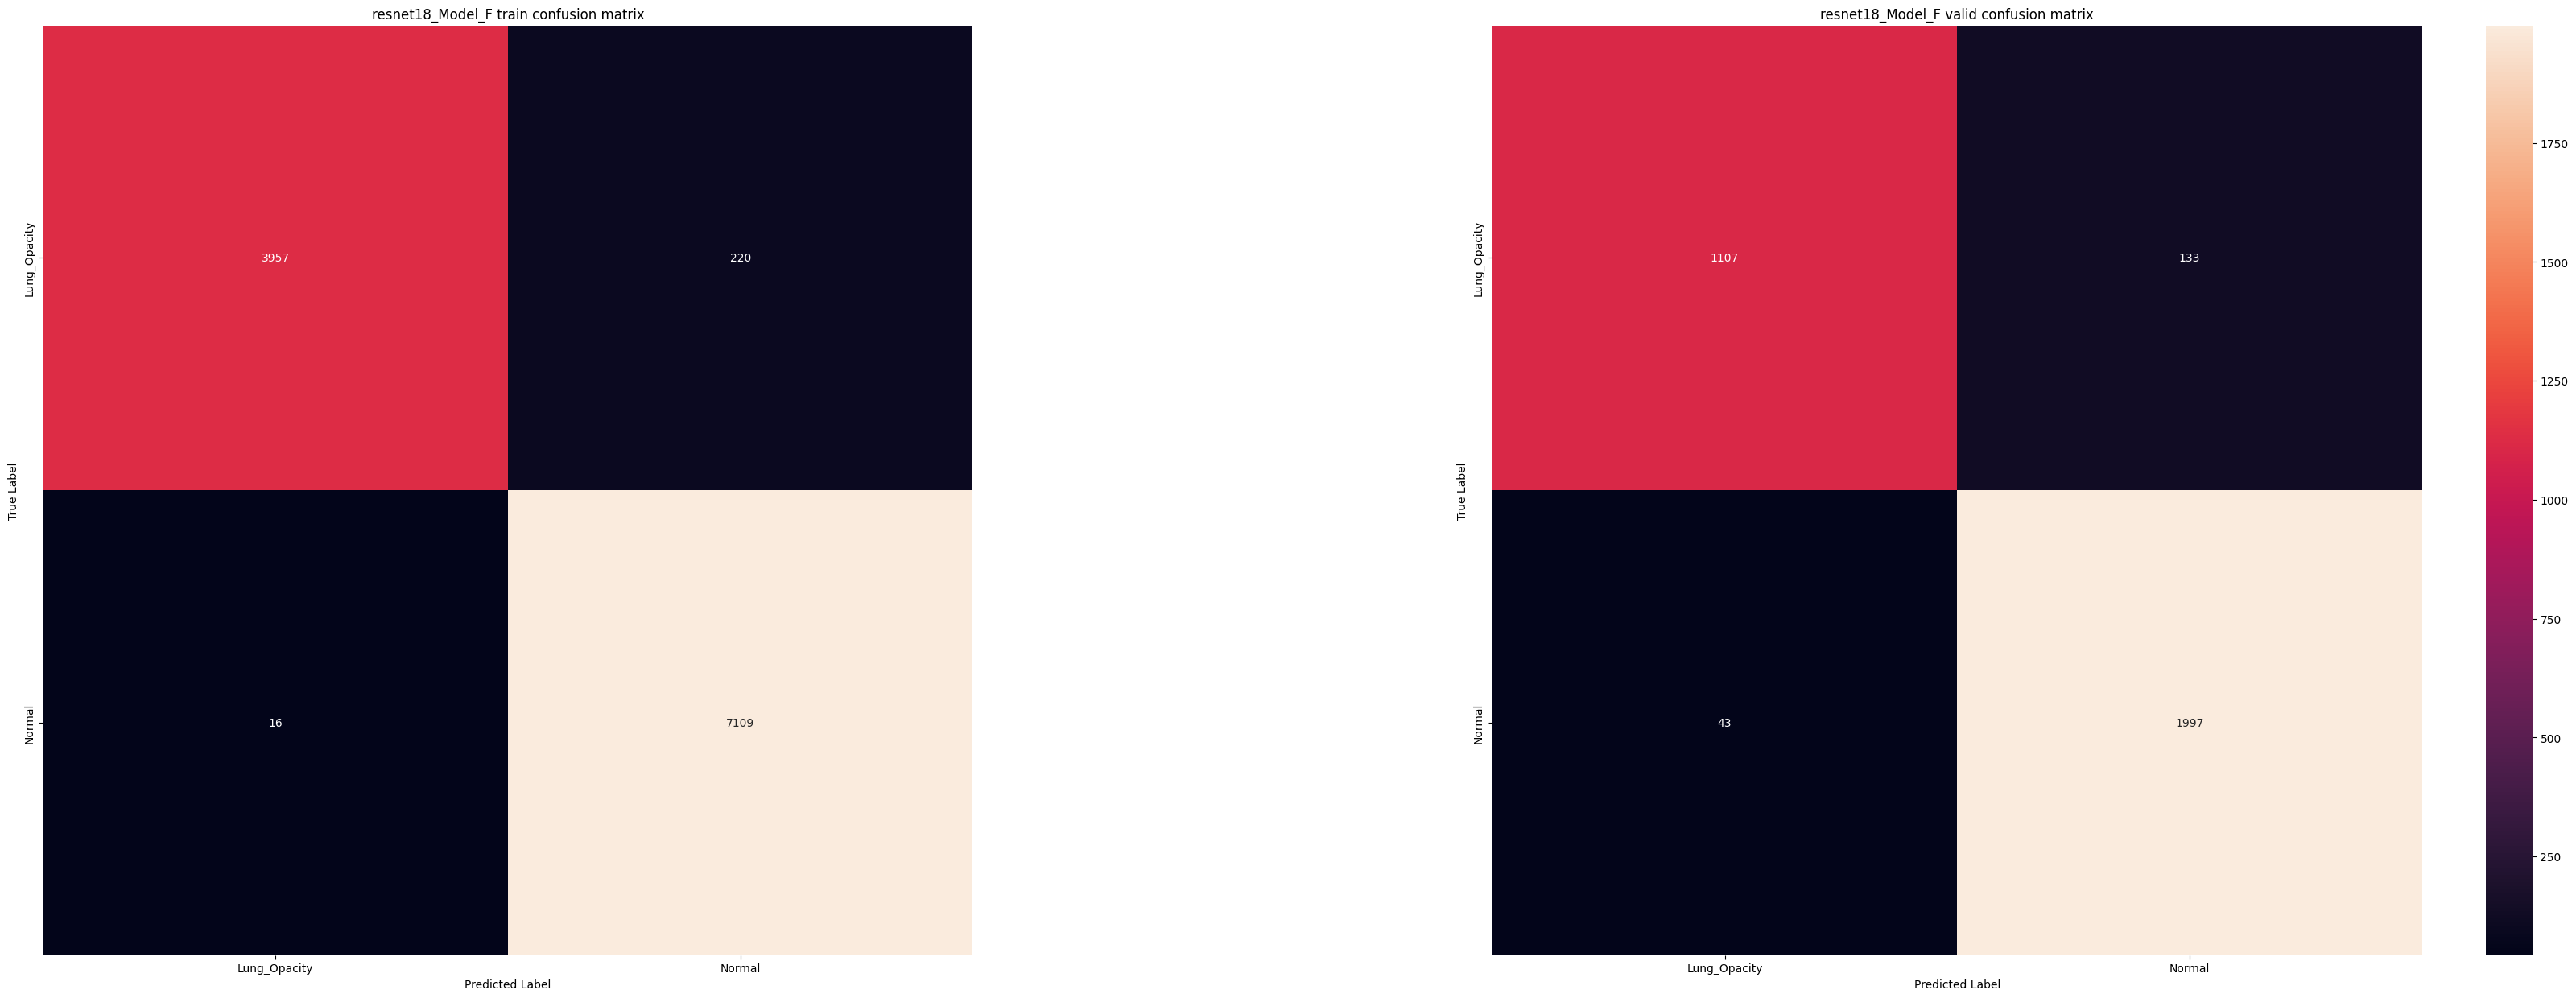

In [82]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)